# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mkhlor006/Flyrank_internship_ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!git clone https://github.com/mkhlor006/Flyrank_internship_ML.git

Cloning into 'Flyrank_internship_ML'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 172 (delta 76), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (172/172), 1.93 MiB | 5.22 MiB/s, done.
Resolving deltas: 100% (76/76), done.


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Work from the GitHub repository in Colab
repo_path = "/content/Flyrank_internship_ML"

if os.path.exists(repo_path):
    os.chdir(repo_path)

print("Working directory:", os.getcwd())

Working directory: /content/Flyrank_internship_ML


In [3]:
!python scripts/01_prepare_features.py

Prepared 30,000 rows from 30,000 raw rows
Wrote /content/Flyrank_internship_ML/data/processed/refresh_feature_vector.csv


In [4]:
data = pd.read_csv(
    "data/processed/refresh_feature_vector.csv"
)

print("Prepared dataset shape:", data.shape)
print("Number of clients:", data["client_id"].nunique())
print("\nTarget distribution:")
print(data["is_declining_label"].value_counts())

Prepared dataset shape: (30000, 52)
Number of clients: 32

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64


## 1. Question

*The research question and the decision it supports.*



## Research question

Can a supervised machine-learning model improve the prioritisation of content pages for human refresh review compared with a transparent rule-based baseline?

The practical decision is not whether a page will definitely improve after a refresh. Instead, the question is whether the model can place a higher concentration of observed declining pages near the top of a review queue.

## Decision supported

The output supports a content team or SEO analyst deciding which pages should be reviewed first. The recommendation is decision-support only: a human should inspect the page, search intent, business context and content quality before any change is made.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



## Data used

The supervised modelling work uses the FlyRank ML Internship anonymized starter dataset and its prepared feature vector. The raw starter dataset contains approximately 30,000 content-page observations; the prepared feature vector used for modelling contains 30,000 rows and 52 fields.

The data is anonymized and does not expose client names, domains, URLs, titles or keywords.

For earlier signal and rule exploration, I also used the FlyRank internship warehouse. The March 2026 partition of `fact_content_daily_performance` contained 9,841,378 daily observations spanning 1 March 2026 to 31 March 2026. The warehouse is much larger than the modelling slice, but I did not claim that the supervised model was trained on the full warehouse release.

## Key data fields

The modelling data contains page-level search and engagement signals including impressions, clicks, sessions, average position, CTR, engagement, scroll behaviour, content age and days since update, together with categorical descriptors such as content type, intent and competition.

## Exclusions

Identifiers such as `content_id` and `client_id` were not used as predictive features. Outcome-derived fields such as `is_declining_label`, `trend_direction` and `trend_pct` were also excluded from the model feature matrix because using them as predictors would leak information about the outcome.

The June sample partition was treated as a final-month/sealed reference rather than being used to develop label logic, consistent with the internship guidance.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



## Outcome definition

The supervised target is `is_declining_label`, a binary label derived from the observed trend direction in the prepared feature vector. A value of 1 represents the declining class and a value of 0 represents the non-declining class.

## Features

The model uses measured search, engagement and content characteristics. Numeric inputs include search volume, competition, CPC, word count, character count, log-transformed impressions, clicks and sessions, visibility days, content age, days since update, CTR, average position, engagement rate, scroll rate and AI-traffic percentage. Categorical inputs include competition level, content type, main intent, age tier, freshness tier, word-count tier, impression tier and position tier.

Identifiers and outcome-derived fields were excluded from the predictive matrix.

## Baseline

The Week-4 baseline is a transparent hand-written refresh-priority score. It provides a simple benchmark for comparison rather than an automated production decision.

## Model choice

I compared Logistic Regression, Decision Tree and Random Forest. Logistic Regression was selected as the primary learned model because it provided the strongest Precision@50 in the evaluation and remains relatively interpretable.

## Primary evaluation metric

The main metric is Precision@50 because the practical use case is ranking pages for a small review queue. Precision@50 measures the proportion of the top 50 ranked pages that are actually in the declining class.

Supporting metrics include accuracy, precision, recall, F1, ROC-AUC and average precision.

## Validation design

The main honest validation design is a client-grouped holdout. Twenty percent of clients are held out for testing, with a fixed random seed of 42. This prevents pages from the same client appearing in both training and test sets.

As a validation audit, I also compared this grouped design with a row-level split. This showed how much measured performance can change when observations from the same client are allowed to cross the train/test boundary.

## Leakage checks

I explicitly checked that the final feature matrix contained no identifiers or outcome-derived fields. The leakage audit returned an empty set of forbidden features.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



## Model comparison

On the original client-holdout evaluation, Logistic Regression achieved the strongest Precision@50 at 0.76. The Week-4 baseline achieved 0.44, the Decision Tree achieved 0.68, and the Random Forest achieved 0.44.

The 0.76 result means that 76% of the top 50 ranked observations were in the declining class under that particular test split. This is a measured ranking result, not proof that the model will perform identically on future clients.

## Validation sensitivity

The validation audit showed a substantial difference between a row-level split and the stricter client-grouped split. Precision@50 was 0.90 for the row-level split and 0.40 for the client-grouped split, with zero client overlap in the grouped evaluation.

I therefore use the grouped result as the more cautious estimate of performance on unseen clients. The large difference demonstrates that validation design materially affects the measured result.

,Model,Precision@50
0,Week-4 Baseline,0.44
1,Logistic Regression,0.76
2,Decision Tree,0.68
3,Random Forest,0.44


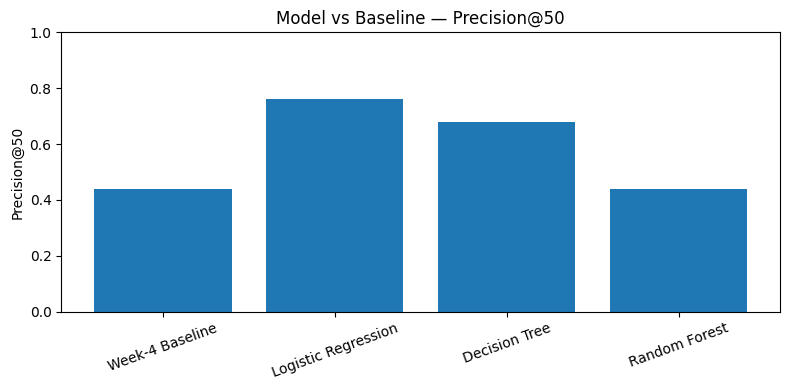

In [5]:
model_results = pd.DataFrame({
    "Model": [
        "Week-4 Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Precision@50": [
        0.44,
        0.76,
        0.68,
        0.44
    ]
})

display(model_results)

plt.figure(figsize=(8, 4))
plt.bar(model_results["Model"], model_results["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Model vs Baseline — Precision@50")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

,Validation design,Precision@50
0,Row-level,0.9
1,Client-grouped,0.4


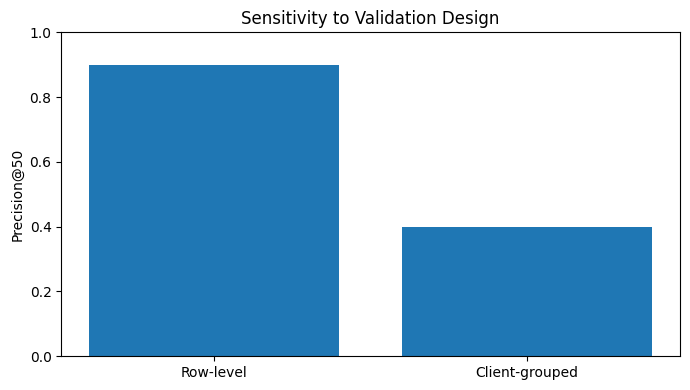

In [6]:
validation_results = pd.DataFrame({
    "Validation design": [
        "Row-level",
        "Client-grouped"
    ],
    "Precision@50": [
        0.90,
        0.40
    ]
})

display(validation_results)

plt.figure(figsize=(7, 4))
plt.bar(
    validation_results["Validation design"],
    validation_results["Precision@50"]
)
plt.ylabel("Precision@50")
plt.title("Sensitivity to Validation Design")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Error analysis

In the original Week-5 Logistic Regression evaluation, the model produced 2,115 correct predictions, 718 false positives and 586 false negatives.

The false-positive cases show that the model can rank a non-declining page as likely to decline. The false-negative cases show that some genuinely declining pages are missed. These errors reinforce the use of the model as decision-support rather than as an automatic content-change system.

In [8]:
# Recreate the Logistic Regression model for the capstone
# so this notebook does not depend on variables from ML-08.

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

# Load the prepared feature data
data = pd.read_csv(
    "data/processed/refresh_feature_vector.csv"
)

# Same feature definitions used in Week 5
NUMERIC_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "log_impressions_90d",
    "log_clicks_90d",
    "log_sessions_90d",
    "log_ai_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

CATEGORICAL_FEATURES = [
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier"
]

# Create a client-grouped train/test split
clients = (
    data["client_id"]
    .fillna("unknown")
    .astype(str)
    .unique()
)

rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(clients)

n_test_clients = max(
    1,
    int(round(len(shuffled_clients) * 0.20))
)

test_clients = set(
    shuffled_clients[:n_test_clients]
)

test_mask = (
    data["client_id"]
    .fillna("unknown")
    .astype(str)
    .isin(test_clients)
)

group_train = data.loc[~test_mask].copy()
group_test = data.loc[test_mask].copy()


# Build feature matrices
def make_features(frame):
    numeric = (
        frame[NUMERIC_FEATURES]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    categorical = (
        frame[CATEGORICAL_FEATURES]
        .fillna("unknown")
        .astype(str)
    )

    categorical = pd.get_dummies(
        categorical,
        prefix=CATEGORICAL_FEATURES,
        dtype=float
    )

    return pd.concat(
        [
            numeric.reset_index(drop=True),
            categorical.reset_index(drop=True)
        ],
        axis=1
    )


X_group_train = make_features(group_train)
X_group_test = make_features(group_test)

# Make train/test feature columns identical
X_group_test = X_group_test.reindex(
    columns=X_group_train.columns,
    fill_value=0
)

y_group_train = (
    group_train["is_declining_label"]
    .astype(int)
    .reset_index(drop=True)
)

y_group_test = (
    group_test["is_declining_label"]
    .astype(int)
    .reset_index(drop=True)
)

# Train Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(
    X_group_train,
    y_group_train
)

# Extract coefficients
fitted_logistic = logistic_model.named_steps["model"]

coefficients = pd.Series(
    fitted_logistic.coef_[0],
    index=X_group_train.columns
)

top_positive = (
    coefficients
    .sort_values(ascending=False)
    .head(5)
)

top_negative = (
    coefficients
    .sort_values(ascending=True)
    .head(5)
)

print("Top 5 features associated with a higher declining prediction:")
display(top_positive.to_frame("coefficient"))

print("\nTop 5 features associated with a lower declining prediction:")
display(top_negative.to_frame("coefficient"))

Top 5 features associated with a higher declining prediction:


,coefficient
log_impressions_90d,1.658755
word_count,1.607656
impression_tier_low,0.245641
word_count_tier_1000-2000,0.184402
days_since_last_update,0.180911



Top 5 features associated with a lower declining prediction:


,coefficient
char_count,-1.351979
log_clicks_90d,-0.656016
avg_position,-0.404586
days_with_impressions,-0.251329
content_age_days,-0.248888


### Feature interpretation

The Logistic Regression coefficients show which features are most strongly associated with the model's declining prediction in the fitted client-grouped model. Positive coefficients increase the model's predicted log-odds of the declining class, while negative coefficients decrease them, holding the other model inputs within the fitted model.

These are model associations, not causal effects. A large coefficient does not mean that changing that feature would cause a page to become more or less likely to decline.

## 5. Limitations

*What this work cannot claim.*



This study has several important limitations.

First, the supervised model was trained on the anonymized 30,000-row starter dataset rather than the full warehouse release. The larger warehouse was used for supporting signal and rule exploration, so the model results should not be described as results from the entire 79M-row release.

Second, the declining label is an operational outcome definition rather than a direct measurement of content quality. A declining page may still be useful, and the label does not establish why performance changed.

Third, the validation audit showed strong sensitivity to split design. Precision@50 changed from 0.90 under a row-level split to 0.40 under a client-grouped split. This limits how confidently the model can be generalised to unseen clients.

Fourth, the data does not fully capture search intent, content quality, business priority, competitor activity, algorithm changes or editorial decisions.

Finally, the model identifies directional prioritisation opportunities. It does not prove that a content refresh will cause higher rankings, more impressions or more clicks.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


The recommendations below are intended to guide human review rather than trigger automatic changes.

### 1. Review mature pages with measurable search visibility

Pages with meaningful observed search performance and evidence of an opportunity should be reviewed first. A reviewer should check whether the page is outdated, incomplete or mismatched to current search intent.

### 2. Improve strong pages before rebuilding them

Pages that already earn impressions may benefit from targeted improvements to clarity, completeness and missing subtopics rather than being replaced from scratch.

### 3. Investigate page-one click capture opportunities

When a page already has strong search visibility, review the title, description and search-intent alignment before considering a full content rewrite.

### 4. Expand thin sections when there is evidence of a content gap

Additional depth should answer missing questions or provide useful examples. Word count alone should not be treated as an objective.

### 5. Review freshness as context, not as an automatic trigger

The FlyRank report finds a strong freshness-window pattern, including a 31–90 day growth-to-decline ratio of 5.43:1, but the report also cautions against reading unstable small cohorts too strongly. Freshness should therefore support review rather than automatically trigger a refresh. :contentReference[oaicite:5]{index=5}

### 6. Prioritise diagnosed problems over invisible demand

A page with an observed issue and measurable opportunity is easier to act on than a page with no measurable evidence of demand.

### 7. Monitor AI traffic separately

AI referral traffic behaves differently from classic organic traffic, so it should be tracked as a separate channel rather than folded into a single generic performance measure. :contentReference[oaicite:6]{index=6}

### 8. Never automate the final editorial decision

The system should not automatically rewrite, delete, publish or merge content. Human review remains necessary because the available features do not capture all editorial and business context.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



The paper embeds two core evaluation charts:

1. Model vs baseline Precision@50.
2. Validation sensitivity: row-level versus client-grouped Precision@50.

The paper also includes the model comparison table and the ranked recommendation output. These artifacts are generated from the notebook so that the published claims remain traceable to the analysis.

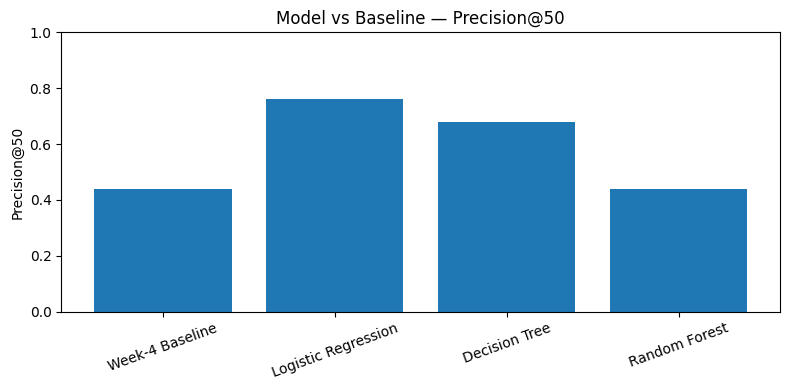

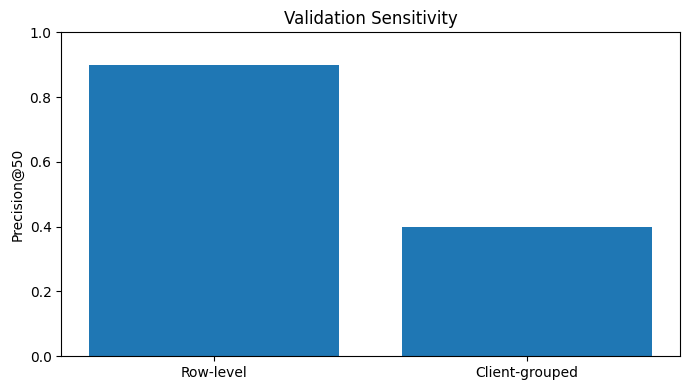

Figures saved in work/figures/


In [9]:
import os

os.makedirs("work/figures", exist_ok=True)

# Chart 1
plt.figure(figsize=(8, 4))
plt.bar(model_results["Model"], model_results["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Model vs Baseline — Precision@50")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline_precision50.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Chart 2
plt.figure(figsize=(7, 4))
plt.bar(
    validation_results["Validation design"],
    validation_results["Precision@50"]
)
plt.ylabel("Precision@50")
plt.title("Validation Sensitivity")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    "work/figures/validation_sensitivity_precision50.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figures saved in work/figures/")

## Abstract

This study asks whether machine learning can improve the prioritisation of content pages for human refresh review compared with a transparent rule-based baseline. Using an anonymized FlyRank internship dataset, I prepared search, engagement and content features and compared Logistic Regression, Decision Tree and Random Forest models under a client-holdout evaluation. Logistic Regression achieved a measured Precision@50 of 0.76 compared with 0.44 for the Week-4 baseline on the original held-out evaluation, while the Decision Tree reached 0.68 and the Random Forest 0.44. A later validation audit showed that Precision@50 changed from 0.90 under a row-level split to 0.40 under a stricter client-grouped split, highlighting the importance of validation design. The resulting playbook is therefore presented as directional decision-support for human review rather than as proof that a page should be refreshed or that a refresh will cause improved performance.

## Introduction / Problem statement

Content teams often have more pages than they can manually review, so they need a way to prioritise which pages deserve attention first. A transparent rule can provide a simple starting point, but a learned model may identify combinations of page characteristics that are difficult to capture with fixed thresholds.

The practical problem in this study is therefore a ranking problem: given observable page characteristics, can a model place a greater concentration of declining pages near the top of a human-review queue than a simple baseline?

The goal is not to automate editorial judgement. The goal is to provide a measurable, reproducible prioritisation signal that can be inspected, validated and challenged.

## Reproducibility

The analysis is stored in the public GitHub repository:

[FlyRank Internship ML Repository](https://github.com/mkhlor006/Flyrank_internship_ML)

Key notebooks:

- `work/notebooks/w03_data_contract.ipynb`
- `work/notebooks/w04_baseline_score.ipynb`
- `work/notebooks/w05_model.ipynb`
- `work/notebooks/w06_validation_audit.ipynb`
- `work/notebooks/w07_action_playbook.ipynb`
- `work/notebooks/capstone.ipynb`

The notebook generates the figures and recommendation artifacts used by the paper.

# ML-12 — Closing communication

## 5-minute demo outline

**Minute 1 — Problem:** Explain why content teams need to prioritise pages for review.

**Minute 2 — Data and method:** Introduce the anonymized dataset, the declining-page target, the baseline and the Logistic Regression model.

**Minute 3 — Results:** Show the Precision@50 comparison and explain the 0.76 model result versus the 0.44 baseline.

**Minute 4 — Validation lesson:** Show the 0.90 row-level versus 0.40 client-grouped result and explain why grouped validation is more cautious.

**Minute 5 — Action:** Show the ranked playbook and explain that recommendations remain human-reviewed decision support rather than automatic content changes.

## Social-post cut

I built and audited a machine-learning workflow for content-refresh prioritisation using anonymized FlyRank internship data. Logistic Regression reached a measured Precision@50 of 0.76 versus 0.44 for the baseline on the original client-holdout evaluation, while a stricter validation audit showed why split design matters. The result is a practical, human-reviewed decision-support workflow rather than an automated content-writing system.

## Employer-facing summary

I built a supervised machine-learning workflow that ranks content pages for human refresh review and compared it with a transparent rule-based baseline. I focused on honest validation, leakage checks and interpretable error analysis, and found that validation design materially changed the measured performance. The project demonstrates practical skills in Python, data preparation, model evaluation, responsible interpretation and translating ML output into an actionable workflow.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
